# **Notebook 2: Distributed Feature Engineering Pipeline**
**Input**: `data/hdfs_parquet/` | **Output**: `data/features_parquet/` – vectorised & scaled feature set

## **1. SparkSession**

In [1]:
import os, time, warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

spark = (
    SparkSession.builder
    .appName("HDFS_Anomaly_FeatureEngineering")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.sql.shuffle.partitions", "100")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .master("local[*]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

BASE_DIR    = "/home/sayan/Lakhveer"
PARQUET_IN  = os.path.join(BASE_DIR, "project", "data", "hdfs_parquet")
PARQUET_OUT = os.path.join(BASE_DIR, "project", "data", "features_parquet")
print(f"Spark version : {spark.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/01 08:33:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/01 08:33:07 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/01 08:33:07 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/01 08:33:07 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/03/01 08:33:07 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


Spark version : 3.5.0


## **2. Load Parquet & Validate**

In [2]:
from pyspark import StorageLevel

df = spark.read.parquet(PARQUET_IN)
df = df.persist(StorageLevel.MEMORY_AND_DISK)

total = df.count()
print(f"Rows: {total:,}  |  Cols: {len(df.columns)}")
df.groupBy('Label').count().show()

26/03/01 08:33:14 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Rows: 3,450,366  |  Cols: 81


+-----+-------+
|Label|  count|
+-----+-------+
|    0|3349338|
|    1| 101028|
+-----+-------+



## **3. Handling Missing Values**

In [3]:
null_counts = df.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]
).collect()[0].asDict()

has_nulls = {k: v for k, v in null_counts.items() if v > 0}
if has_nulls:
    print(f"Columns with nulls: {has_nulls}")
else:
    print("No null values found. ✓")

from pyspark.ml.feature import Imputer

event_cols = [f"E{i}" for i in range(1, 30)]
stat_cols  = ['total_events', 'mean_event_count', 'std_event_count',
              'max_event_count', 'min_event_count', 'nonzero_events',
              'event_sparsity', 'event_concentration', 'event_balance']

imputer = Imputer(
    strategy="median",
    inputCols=event_cols + stat_cols,
    outputCols=event_cols + stat_cols,
)
imputer_model = imputer.fit(df)
df_imputed    = imputer_model.transform(df)
print("Imputer fitted (median strategy).")

No null values found. ✓


Imputer fitted (median strategy).


## **4. Custom Transformer – EventCategoryAggregator**

In [4]:
from pyspark.ml import Transformer
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
from pyspark.sql import DataFrame
import pyspark.sql.functions as F

class EventCategoryAggregator(Transformer, DefaultParamsReadable, DefaultParamsWritable):
    CATEGORY_MAP = {
        "cat_data_transfer": ["E2","E5","E9","E11","E21","E23","E25","E26"],
        "cat_error"        : ["E4","E6","E7","E8","E22"],
        "cat_replication"  : ["E3","E15","E16","E19"],
        "cat_admin"        : ["E14","E18","E24","E27","E28","E29"],
    }

    def _transform(self, dataset: DataFrame) -> DataFrame:
        for cat_col, events in self.CATEGORY_MAP.items():
            dataset = dataset.withColumn(cat_col, sum(F.col(e) for e in events))
        dataset = dataset.withColumn(
            "error_ratio",
            F.when(F.col("total_events") > 0,
                   F.col("cat_error") / F.col("total_events")
            ).otherwise(F.lit(0.0))
        )
        return dataset

cat_aggregator = EventCategoryAggregator()
df_cats = cat_aggregator.transform(df_imputed)

new_cols = list(EventCategoryAggregator.CATEGORY_MAP.keys()) + ["error_ratio"]
print("Category features added:", new_cols)
df_cats.select(new_cols + ["Label"]).show(5, truncate=False)

Category features added: ['cat_data_transfer', 'cat_error', 'cat_replication', 'cat_admin', 'error_ratio']
+-----------------+---------+---------------+---------+-------------------+-----+
|cat_data_transfer|cat_error|cat_replication|cat_admin|error_ratio        |Label|
+-----------------+---------+---------------+---------+-------------------+-----+
|11.8             |0.95     |0.0            |0.95     |0.07306318417819235|0    |
|17.7             |0.95     |0.0            |0.95     |0.04999847201100107|0    |
|22.65            |2.9      |1.95           |0.0      |0.11598050242656552|0    |
|17.7             |3.9      |1.9            |0.0      |0.17719686768755924|0    |
|17.7             |0.95     |0.0            |0.0      |0.04999342140157605|0    |
+-----------------+---------+---------------+---------+-------------------+-----+
only showing top 5 rows



In [5]:
df_eng = (
    df_cats
    .withColumn("log_total_events",      F.log1p(F.col("total_events")))
    .withColumn("log_cat_data_transfer", F.log1p(F.col("cat_data_transfer")))
    .withColumn("log_cat_error",         F.log1p(F.col("cat_error")))
    .withColumn("has_error",             (F.col("cat_error") > 0).cast(DoubleType()))
    .withColumn("high_sparsity",         (F.col("event_sparsity") > 0.7).cast(DoubleType()))
)
print("Extra engineered columns added.")
extra = ['log_total_events','log_cat_data_transfer','log_cat_error','has_error','high_sparsity']
df_eng.select(extra + ['Label']).show(5)

Extra engineered columns added.
+------------------+---------------------+------------------+---------+-------------+-----+
|  log_total_events|log_cat_data_transfer|     log_cat_error|has_error|high_sparsity|Label|
+------------------+---------------------+------------------+---------+-------------+-----+
|2.6392319241843007|   2.5494451709255714|0.6678293725756554|      1.0|          0.0|    0|
| 2.995761305810763|    2.928523523860541|0.6678293725756554|      1.0|          0.0|    0|
|3.2582581699449675|   3.1633631149379418|1.3609765531356006|      1.0|          0.0|    0|
|3.1359036277351247|    2.928523523860541| 1.589235205116581|      1.0|          0.0|    0|
|2.9958572755587576|    2.928523523860541|0.6678293725756554|      1.0|          0.0|    0|
+------------------+---------------------+------------------+---------+-------------+-----+
only showing top 5 rows



## **5. Feature Vector Assembly**

In [6]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, MinMaxScaler

FEATURE_COLS = (
    event_cols
    + stat_cols
    + list(EventCategoryAggregator.CATEGORY_MAP.keys())
    + ['error_ratio', 'log_total_events', 'log_cat_data_transfer',
       'log_cat_error', 'has_error', 'high_sparsity']
)
interaction_cols = [
    'E5_E26_interaction','E5_E26_ratio',
    'E5_E11_interaction','E5_E11_ratio',
    'E5_E9_interaction', 'E5_E9_ratio',
    'E11_E9_interaction','E11_E9_ratio',
]
FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS + interaction_cols))

df_clean = df_eng
for c in FEATURE_COLS:
    df_clean = df_clean.withColumn(
        c, F.when(F.col(c).isNull() | F.isnan(c), 0.0).otherwise(F.col(c))
    )

assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="raw_features", handleInvalid="skip")
df_vec    = assembler.transform(df_clean)
print(f"Feature vector dimension: {len(FEATURE_COLS)}")
df_vec.select('raw_features', 'Label').show(3, truncate=True)

Feature vector dimension: 56


+--------------------+-----+
|        raw_features|Label|
+--------------------+-----+
|(56,[4,8,10,21,23...|    0|
|(56,[4,8,10,13,20...|    0|
|(56,[1,2,3,4,8,10...|    0|
+--------------------+-----+
only showing top 3 rows



## **6. Scaling: StandardScaler & MinMaxScaler**

In [7]:
std_scaler       = StandardScaler(inputCol="raw_features", outputCol="std_features",
                                   withMean=True, withStd=True)
std_scaler_model = std_scaler.fit(df_vec)
df_std           = std_scaler_model.transform(df_vec)

mm_scaler        = MinMaxScaler(inputCol="raw_features", outputCol="mm_features")
mm_scaler_model  = mm_scaler.fit(df_vec)
df_scaled        = mm_scaler_model.transform(df_std)

print("StandardScaler and MinMaxScaler fitted and applied.")
df_scaled.select('std_features', 'mm_features', 'Label').show(3, truncate=True)

StandardScaler and MinMaxScaler fitted and applied.
+--------------------+--------------------+-----+
|        std_features|         mm_features|Label|
+--------------------+--------------------+-----+
|[-0.2034766903455...|(56,[4,8,10,23,25...|    0|
|[-0.2034766903455...|(56,[4,8,10,13,20...|    0|
|[-0.2034766903455...|(56,[1,2,3,4,8,10...|    0|
+--------------------+--------------------+-----+
only showing top 3 rows



## **7. PCA – Dimensionality Reduction**

26/03/01 08:42:08 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/01 08:42:08 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/03/01 08:44:43 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


PCA – top-20 components:
  PC 1: var=0.2150  cumulative=0.2150
  PC 2: var=0.1174  cumulative=0.3324
  PC 3: var=0.0687  cumulative=0.4011
  PC 4: var=0.0497  cumulative=0.4507
  PC 5: var=0.0368  cumulative=0.4876
  PC 6: var=0.0339  cumulative=0.5215
  PC 7: var=0.0207  cumulative=0.5422
  PC 8: var=0.0199  cumulative=0.5620
  PC 9: var=0.0193  cumulative=0.5814
  PC10: var=0.0189  cumulative=0.6002
  PC11: var=0.0188  cumulative=0.6190
  PC12: var=0.0188  cumulative=0.6378
  PC13: var=0.0188  cumulative=0.6566
  PC14: var=0.0187  cumulative=0.6753
  PC15: var=0.0187  cumulative=0.6940
  PC16: var=0.0187  cumulative=0.7127
  PC17: var=0.0187  cumulative=0.7314
  PC18: var=0.0187  cumulative=0.7501
  PC19: var=0.0187  cumulative=0.7688
  PC20: var=0.0186  cumulative=0.7874


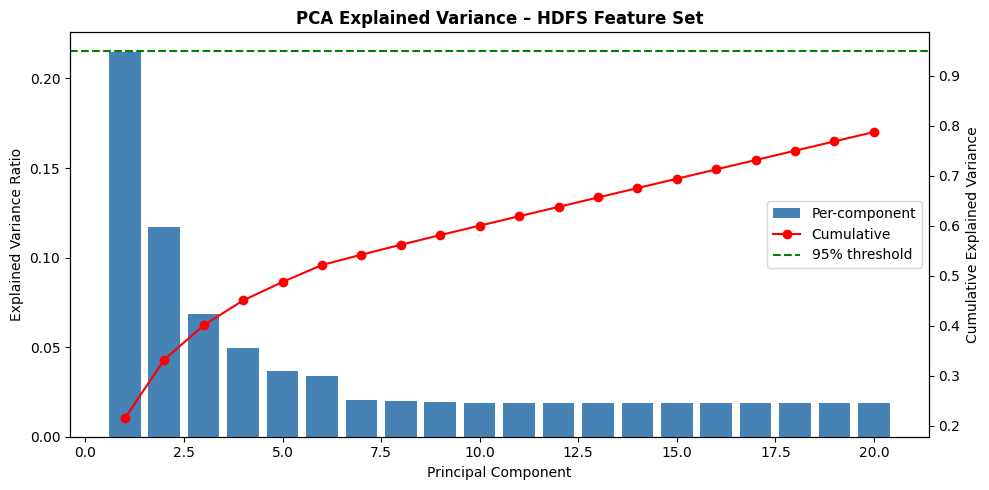

In [8]:
from pyspark.ml.feature import PCA
import numpy as np

N_COMPONENTS = 20
pca       = PCA(k=N_COMPONENTS, inputCol="std_features", outputCol="pca_features")
pca_model = pca.fit(df_scaled)
df_pca    = pca_model.transform(df_scaled)

explained_var = pca_model.explainedVariance.toArray()
cumulative    = np.cumsum(explained_var)

print(f"PCA – top-{N_COMPONENTS} components:")
for i, (ev, cum) in enumerate(zip(explained_var, cumulative)):
    print(f"  PC{i+1:2d}: var={ev:.4f}  cumulative={cum:.4f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, N_COMPONENTS+1), explained_var, color='steelblue', label='Per-component')
ax2 = ax.twinx()
ax2.plot(range(1, N_COMPONENTS+1), cumulative, 'r-o', label='Cumulative')
ax2.axhline(0.95, color='green', linestyle='--', label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax2.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Explained Variance – HDFS Feature Set', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'project/data/samples/pca_explained_variance.png'), bbox_inches='tight')
plt.show()

## **8. Class Imbalance – Oversampling Strategy**

In [9]:
label_counts = df_scaled.groupBy('Label').count().collect()
counts_dict  = {row['Label']: row['count'] for row in label_counts}
n0, n1       = counts_dict.get(0, 0), counts_dict.get(1, 0)
ratio        = n0 / max(n1, 1)
print(f"Normal  (0): {n0:,}")
print(f"Anomaly (1): {n1:,}")
print(f"Ratio       : {ratio:.1f}:1")

if ratio > 2 and n1 > 0:
    oversample_factor = int(n0 / n1)
    minority_df = df_scaled.filter(F.col('Label') == 1)
    oversampled = minority_df
    for _ in range(oversample_factor - 1):
        oversampled = oversampled.union(minority_df)
    df_balanced = df_scaled.filter(F.col('Label') == 0).union(oversampled)
    df_balanced = df_balanced.repartition(100)
    print("Oversampled – new distribution:")
    df_balanced.groupBy('Label').count().show()
else:
    df_balanced = df_scaled
    print("Classes balanced – no oversampling required.")

w0 = (1.0 / n0) * (n0 + n1) / 2.0
w1 = (1.0 / max(n1, 1)) * (n0 + n1) / 2.0
print(f"\nClass weights: Normal={w0:.4f}  Anomaly={w1:.4f}")

df_weighted = df_scaled.withColumn(
    "class_weight",
    F.when(F.col('Label') == 0, w0).otherwise(w1)
)

Normal  (0): 3,349,338
Anomaly (1): 101,028
Ratio       : 33.2:1
Oversampled – new distribution:


26/03/01 08:47:04 WARN DAGScheduler: Broadcasting large task binary with size 14.7 MiB
26/03/01 08:49:24 WARN DAGScheduler: Broadcasting large task binary with size 8.2 MiB
26/03/01 08:49:40 WARN DAGScheduler: Broadcasting large task binary with size 8.2 MiB


+-----+-------+
|Label|  count|
+-----+-------+
|    1|3333924|
|    0|3349338|
+-----+-------+


Class weights: Normal=0.5151  Anomaly=17.0763


## **9. Train / Validation / Test Split (60 / 20 / 20)**

In [10]:
checkpoint_path = os.path.join(BASE_DIR, "project", "data", "checkpoints", "weighted_checkpoint")
print("Checkpointing df_weighted to disk to break query plan lineage...")
t0 = time.time()
df_weighted.write.mode("overwrite").option("compression", "snappy").parquet(checkpoint_path)
print(f"Checkpoint written in {time.time()-t0:.1f}s")

df_checkpoint = spark.read.parquet(checkpoint_path)

df_fold = df_checkpoint.withColumn(
    "rand_val", F.rand(seed=42)
).withColumn(
    "split",
    F.when(F.col("rand_val") < 0.6, "train")
     .when(F.col("rand_val") < 0.8, "val")
     .otherwise("test")
)

train_df = df_fold.filter(F.col("split") == "train").drop("rand_val", "split")
val_df   = df_fold.filter(F.col("split") == "val").drop("rand_val", "split")
test_df  = df_fold.filter(F.col("split") == "test").drop("rand_val", "split")

n_train, n_val, n_test = train_df.count(), val_df.count(), test_df.count()
total_split = n_train + n_val + n_test
print(f"Train: {n_train:>10,}  ({100*n_train/total_split:.1f}%)")
print(f"Val  : {n_val:>10,}  ({100*n_val/total_split:.1f}%)")
print(f"Test : {n_test:>10,}  ({100*n_test/total_split:.1f}%)")

print("\nLabel distribution in splits:")
for name, sp in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = {r['Label']: r['count'] for r in sp.groupBy('Label').count().collect()}
    n = counts.get(0,0) + counts.get(1,0)
    print(f"  {name}: Normal={counts.get(0,0):,} ({100*counts.get(0,0)/max(n,1):.1f}%)  "
          f"Anomaly={counts.get(1,0):,} ({100*counts.get(1,0)/max(n,1):.1f}%)")

Checkpointing df_weighted to disk to break query plan lineage...


Checkpoint written in 241.3s
Train:  2,071,469  (60.0%)
Val  :    689,702  (20.0%)
Test :    689,195  (20.0%)

Label distribution in splits:
  Train: Normal=2,011,037 (97.1%)  Anomaly=60,432 (2.9%)
  Val: Normal=669,456 (97.1%)  Anomaly=20,246 (2.9%)
  Test: Normal=668,845 (97.0%)  Anomaly=20,350 (3.0%)


## **10. Persist Engineered Datasets**

In [11]:
write_cols = ['std_features', 'mm_features', 'pca_features', 'raw_features',
              'Label', 'class_weight']

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    out_path = os.path.join(PARQUET_OUT, split_name)
    t0       = time.time()
    avail    = [c for c in write_cols if c in split_df.columns]
    (
        split_df.select(avail)
        .write
        .mode("overwrite")
        .option("compression", "snappy")
        .parquet(out_path)
    )
    print(f"  {split_name:5s} written in {time.time()-t0:.1f}s")

print("\nAll splits written.")

import json
feat_meta = {
    "feature_cols"  : FEATURE_COLS,
    "n_features"    : len(FEATURE_COLS),
    "pca_components": N_COMPONENTS,
    "class_weights" : {"0": w0, "1": w1},
    "splits"        : {"train": n_train, "val": n_val, "test": n_test},
}
with open(os.path.join(BASE_DIR, "project", "data", "schemas", "feature_metadata.json"), "w") as fp:
    json.dump(feat_meta, fp, indent=2)
print("Feature metadata saved.")

  train written in 19.0s


  val   written in 8.7s


  test  written in 8.2s

All splits written.
Feature metadata saved.


In [13]:
PIPELINE_PATH = os.path.join(BASE_DIR, "project", "data", "pipeline_stages")
os.makedirs(PIPELINE_PATH, exist_ok=True)

imputer_model.write().overwrite().save(os.path.join(PIPELINE_PATH, "imputer_model"))
std_scaler_model.write().overwrite().save(os.path.join(PIPELINE_PATH, "std_scaler_model"))
mm_scaler_model.write().overwrite().save(os.path.join(PIPELINE_PATH, "mm_scaler_model"))
pca_model.write().overwrite().save(os.path.join(PIPELINE_PATH, "pca_model"))
print("Preprocessing pipeline stages saved.")

for cached in [df, train_df, val_df, test_df]:
    cached.unpersist()
print("\n✓  Notebook 2 complete.")

Preprocessing pipeline stages saved.

✓  Notebook 2 complete.
